In [95]:
import torch
import torch.nn.functional as F
import pandas as pd
import numpy as np
from pathlib import Path
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

# 導入您的模型和數據加載器
import sys
sys.path.append('./ex4')
from model import build_model, CLASS_NAMES
from dataloader import XrayTestDataset, build_transforms

print("✅ 所有必要的庫已導入")

✅ 所有必要的庫已導入


In [138]:
model_path = 'ex4/result/efficientnet_b2_cropped_wce/weights/best.pt'

In [139]:
# 設定設備
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"使用設備: {device}")

# 加載模型
print(f"\n正在加載模型: {model_path}")
checkpoint = torch.load(model_path, map_location=device)

# 檢查 checkpoint 中的鍵
print(f"\nCheckpoint 中的鍵: {list(checkpoint.keys())}")

model_name = "efficientnet_b2"  
img_size = 384

# 建立模型
model = build_model(model_name=model_name, pretrained=False, num_classes=len(CLASS_NAMES))

# 根據 checkpoint 的結構加載模型權重
if 'model_state_dict' in checkpoint:
    model.load_state_dict(checkpoint['model_state_dict'])
elif 'model' in checkpoint:
    model.load_state_dict(checkpoint['model'])
elif 'state_dict' in checkpoint:
    model.load_state_dict(checkpoint['state_dict'])
else:
    # 如果 checkpoint 直接就是 state_dict
    model.load_state_dict(checkpoint)

model = model.to(device)
model.eval()

print(f"\n✅ 模型加載成功!")

使用設備: cuda

正在加載模型: ex4/result/efficientnet_b2_cropped_wce/weights/best.pt

Checkpoint 中的鍵: ['features.0.0.weight', 'features.0.1.weight', 'features.0.1.bias', 'features.0.1.running_mean', 'features.0.1.running_var', 'features.0.1.num_batches_tracked', 'features.1.0.block.0.0.weight', 'features.1.0.block.0.1.weight', 'features.1.0.block.0.1.bias', 'features.1.0.block.0.1.running_mean', 'features.1.0.block.0.1.running_var', 'features.1.0.block.0.1.num_batches_tracked', 'features.1.0.block.1.fc1.weight', 'features.1.0.block.1.fc1.bias', 'features.1.0.block.1.fc2.weight', 'features.1.0.block.1.fc2.bias', 'features.1.0.block.2.0.weight', 'features.1.0.block.2.1.weight', 'features.1.0.block.2.1.bias', 'features.1.0.block.2.1.running_mean', 'features.1.0.block.2.1.running_var', 'features.1.0.block.2.1.num_batches_tracked', 'features.1.1.block.0.0.weight', 'features.1.1.block.0.1.weight', 'features.1.1.block.0.1.bias', 'features.1.1.block.0.1.running_mean', 'features.1.1.block.0.1.running_var

In [140]:
# 準備測試數據
test_csv_path = "csv/test_data_sample.csv"
test_img_dir = "no_exp/cropped/test_images"

print(f"測試集 CSV: {test_csv_path}")
print(f"測試集圖像目錄: {test_img_dir}")

# 建立轉換和數據集
transform = build_transforms(img_size=img_size)
test_dataset = XrayTestDataset(test_csv_path, test_img_dir, transform=transform)

print(f"✅ 測試集準備完成")
print(f"   總共 {len(test_dataset)} 張測試圖像")

測試集 CSV: csv/test_data_sample.csv
測試集圖像目錄: no_exp/cropped/test_images
✅ 測試集準備完成
   總共 1182 張測試圖像


In [141]:
# 對測試集進行預測
print("\n🔄 正在對測試集進行預測...")

all_predictions = []
all_confidences = []
all_filenames = []
all_probabilities = []

with torch.no_grad():
    for i in tqdm(range(len(test_dataset)), desc="預測進度"):
        image, filename = test_dataset[i]
        image = image.unsqueeze(0).to(device)  # 添加 batch 維度
        
        # 前向傳播
        outputs = model(image)
        
        # 獲取概率分佈（使用 softmax）
        probs = F.softmax(outputs, dim=1)
        
        # 獲取預測類別和置信度
        confidence, predicted = torch.max(probs, 1)
        
        all_predictions.append(predicted.item())
        all_confidences.append(confidence.item())
        all_filenames.append(filename)
        all_probabilities.append(probs.cpu().numpy()[0])

print(f"✅ 預測完成!")
print(f"   共預測了 {len(all_predictions)} 張圖像")


🔄 正在對測試集進行預測...


預測進度: 100%|██████████| 1182/1182 [00:21<00:00, 54.74it/s]

✅ 預測完成!
   共預測了 1182 張圖像


In [142]:
# 創建預測結果的 DataFrame
results_df = pd.DataFrame({
    'filename': all_filenames,
    'predicted_class': [CLASS_NAMES[pred] for pred in all_predictions],
    'predicted_class_idx': all_predictions,
    'confidence': all_confidences
})

# 添加每個類別的概率
for i, class_name in enumerate(CLASS_NAMES):
    results_df[f'prob_{class_name}'] = [probs[i] for probs in all_probabilities]

# 顯示基本統計
print("\n" + "="*80)
print("預測結果統計")
print("="*80)
print(f"\n各類別預測分佈:")
print(results_df['predicted_class'].value_counts().sort_index())

print(f"\n置信度統計:")
print(results_df['confidence'].describe())


預測結果統計

各類別預測分佈:
predicted_class
COVID-19     13
bacteria    549
normal      313
virus       307
Name: count, dtype: int64

置信度統計:
count    1182.000000
mean        0.954241
std         0.103644
min         0.411460
25%         0.976898
50%         0.998739
75%         0.999959
max         1.000000
Name: confidence, dtype: float64


In [143]:
# 篩選高信心的偽標籤
confidence_thresholds = [0.90, 0.95, 0.98, 0.99]
threshold_stats = {}

for threshold in confidence_thresholds:
    high_conf_mask = results_df['confidence'] >= threshold
    high_conf_df = results_df[high_conf_mask].copy()
    
    print(f"\n📊 置信度閾值 >= {threshold:.2f}:")
    print(f"   篩選出 {len(high_conf_df)} 張圖像 ({len(high_conf_df)/len(results_df)*100:.2f}%)")
    
    if len(high_conf_df) > 0:
        print(f"   平均置信度: {high_conf_df['confidence'].mean():.4f}")
        print(f"   置信度範圍: [{high_conf_df['confidence'].min():.4f}, {high_conf_df['confidence'].max():.4f}]")
        print(f"\n   各類別分佈:")
        
        class_dist = high_conf_df['predicted_class'].value_counts()
        for class_name in CLASS_NAMES:
            count = class_dist.get(class_name, 0)
            percentage = (count / len(high_conf_df) * 100) if len(high_conf_df) > 0 else 0
            avg_conf = high_conf_df[high_conf_df['predicted_class'] == class_name]['confidence'].mean()
            avg_conf_str = f"{avg_conf:.4f}" if not pd.isna(avg_conf) else "N/A"
            print(f"      {class_name:12s}: {count:4d} ({percentage:5.2f}%) - 平均置信度: {avg_conf_str}")
    
    threshold_stats[threshold] = {
        'count': len(high_conf_df),
        'percentage': len(high_conf_df)/len(results_df)*100,
        'df': high_conf_df
    }

print("="*80)


📊 置信度閾值 >= 0.90:
   篩選出 1026 張圖像 (86.80%)
   平均置信度: 0.9900
   置信度範圍: [0.9004, 1.0000]

   各類別分佈:
      normal      :  289 (28.17%) - 平均置信度: 0.9921
      bacteria    :  480 (46.78%) - 平均置信度: 0.9928
      virus       :  244 (23.78%) - 平均置信度: 0.9819
      COVID-19    :   13 ( 1.27%) - 平均置信度: 0.9900

📊 置信度閾值 >= 0.95:
   篩選出 943 張圖像 (79.78%)
   平均置信度: 0.9955
   置信度範圍: [0.9523, 1.0000]

   各類別分佈:
      normal      :  272 (28.84%) - 平均置信度: 0.9962
      bacteria    :  452 (47.93%) - 平均置信度: 0.9967
      virus       :  207 (21.95%) - 平均置信度: 0.9918
      COVID-19    :   12 ( 1.27%) - 平均置信度: 0.9958

📊 置信度閾值 >= 0.98:
   篩選出 862 張圖像 (72.93%)
   平均置信度: 0.9979
   置信度範圍: [0.9800, 1.0000]

   各類別分佈:
      normal      :  255 (29.58%) - 平均置信度: 0.9979
      bacteria    :  421 (48.84%) - 平均置信度: 0.9986
      virus       :  175 (20.30%) - 平均置信度: 0.9961
      COVID-19    :   11 ( 1.28%) - 平均置信度: 0.9976

📊 置信度閾值 >= 0.99:
   篩選出 804 張圖像 (68.02%)
   平均置信度: 0.9988
   置信度範圍: [0.9901, 1.0000]

   各類別分佈:
      norma

## 測試集分布分析與調整策略

已知測試集的真實分布為：
- **normal**: 26.65%
- **bacteria**: 47.04%
- **virus**: 25.30%
- **COVID-19**: 1.02%

1. 檢查模型預測分布是否與真實分布相符
2. 針對預測過多或過少的類別調整閾值
3. 識別可能的系統性偏差


📊 測試集分布對比分析

類別                   真實分布         預測分布           差異           狀態
--------------------------------------------------------------------------------
normal             26.65%       27.83%       +1.18%         ✅ 正常
bacteria           47.04%       47.88%       +0.85%         ✅ 正常
virus              25.30%       23.10%       -2.20%         ✅ 正常
COVID-19            1.02%        1.18%       +0.17%         ✅ 正常


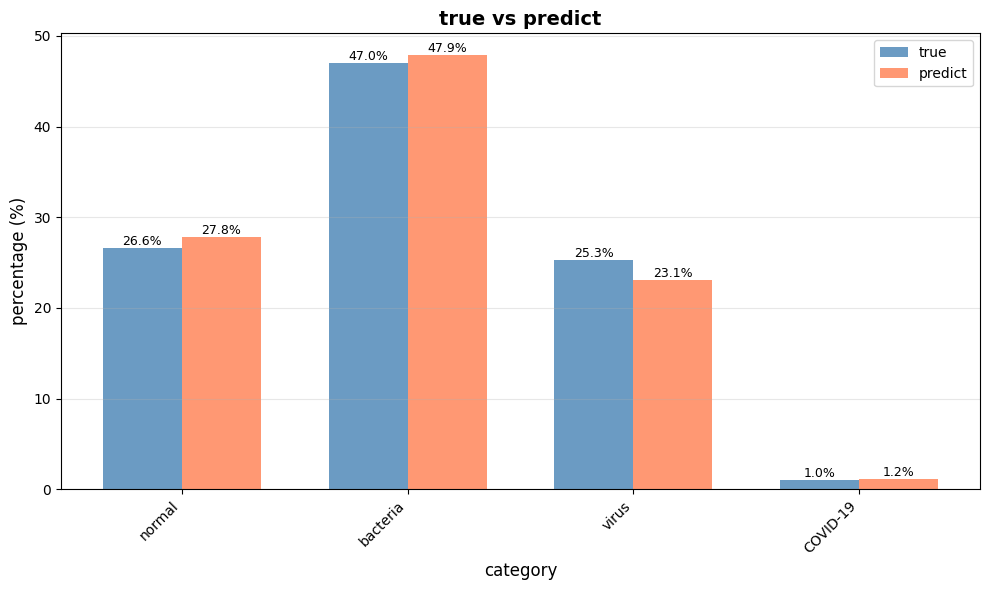


✅ 分布對比分析圖已保存為 'test_distribution_analysis.png'


In [136]:
# 已知的測試集真實分布
true_test_distribution = {
    'normal': 0.266497,
    'bacteria': 0.470389,
    'virus': 0.252961,
    'COVID-19': 0.010152
}

# 計算模型預測的分布
predicted_distribution = results_df['predicted_class'].value_counts(normalize=True).to_dict()

# 創建對比分析
print("\n" + "="*80)
print("📊 測試集分布對比分析")
print("="*80)
print(f"\n{'類別':<12} {'真實分布':>12} {'預測分布':>12} {'差異':>12} {'狀態':>12}")
print("-"*80)

distribution_analysis = {}
for class_name in CLASS_NAMES:
    true_pct = true_test_distribution.get(class_name, 0) * 100
    pred_pct = predicted_distribution.get(class_name, 0) * 100
    diff = pred_pct - true_pct
    
    # 判斷預測狀態
    if abs(diff) < 5:
        status = "✅ 正常"
    elif diff > 0:
        status = "⚠️ 過多"
    else:
        status = "⚠️ 過少"
    
    print(f"{class_name:<12} {true_pct:>11.2f}% {pred_pct:>11.2f}% {diff:>+11.2f}% {status:>12}")
    
    distribution_analysis[class_name] = {
        'true_pct': true_pct,
        'pred_pct': pred_pct,
        'diff': diff,
        'status': status
    }

print("="*80)

# 可視化分布對比
fig, axes = plt.subplots(1, 1, figsize=(10, 6))

# 1. 真實分布 vs 預測分布
x = np.arange(len(CLASS_NAMES))
width = 0.35

true_values = [true_test_distribution[c] * 100 for c in CLASS_NAMES]
pred_values = [predicted_distribution.get(c, 0) * 100 for c in CLASS_NAMES]
ax1 = axes
bars1 = ax1.bar(x - width/2, true_values, width, label='true', color='steelblue', alpha=0.8)
bars2 = ax1.bar(x + width/2, pred_values, width, label='predict', color='coral', alpha=0.8)

ax1.set_xlabel('category', fontsize=12)
ax1.set_ylabel('percentage (%)', fontsize=12)
ax1.set_title('true vs predict', fontsize=14, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(CLASS_NAMES, rotation=45, ha='right')
ax1.legend()
ax1.grid(True, alpha=0.3, axis='y')

# 在柱狀圖上標註數值
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1f}%',
                ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('test_distribution_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✅ 分布對比分析圖已保存為 'test_distribution_analysis.png'")

In [145]:
# 合併偽標籤到訓練集
import shutil
from pathlib import Path

# 設定路徑
train_csv_path = 'csv/train_data.csv'
train_img_dir = Path('no_exp/cropped/train_images')
test_img_dir = Path('no_exp/cropped/test_images')

recommended_threshold = 0.90
# 讀取原始訓練集
train_df = pd.read_csv(train_csv_path)
print(f"\n原始訓練集: {len(train_df)} 張圖像")
print(f"各類別分佈:")
for class_name in CLASS_NAMES:
    count = train_df[class_name].sum()
    percentage = (count / len(train_df)) * 100
    print(f"   {class_name:12s}: {count:4d} ({percentage:5.2f}%)")

pseudo_csv_path = f'csv/pseudo_labels_conf{recommended_threshold:.2f}.csv'
strategy_name = f"統一閾值 ({recommended_threshold:.2f})"

# 讀取偽標籤
pseudo_df = pd.read_csv(pseudo_csv_path)
print(f"\n偽標籤集: {len(pseudo_df)} 張圖像")
print(f"各類別分佈:")
for class_name in CLASS_NAMES:
    count = pseudo_df[class_name].sum()
    percentage = (count / len(pseudo_df)) * 100
    print(f"   {class_name:12s}: {count:4d} ({percentage:5.2f}%)")

# 只針對特定類別進行合併
goal_class = "virus"
print(f"\n僅合併偽標籤中屬於 '{goal_class}' 類別的樣本")
# 合併數據集
combined_df = pd.concat([train_df, pseudo_df[pseudo_df[goal_class] == 1]], ignore_index=True)
combined_csv_path = 'csv/train_data_with_pseudo_virus.csv'
combined_df.to_csv(combined_csv_path, index=False)

print(f"\n✅ 合併後的訓練集: {len(combined_df)} 張圖像")
print(f"   已保存至: {combined_csv_path}")
print(f"\n各類別最終分佈:")
for class_name in CLASS_NAMES:
    count = combined_df[class_name].sum()
    percentage = (count / len(combined_df)) * 100
    original_count = train_df[class_name].sum()
    pseudo_count = pseudo_df[class_name].sum()
    print(f"   {class_name:12s}: {count:4d} ({percentage:5.2f}%) [原始:{original_count:4d} + 偽標籤:{pseudo_count:4d}]")

print("\n" + "-"*80)
print("增長統計:")
total_increase = len(pseudo_df)
increase_percentage = (total_increase / len(train_df)) * 100
print(f"   新增樣本: {total_increase} 張")
print(f"   增長率: {increase_percentage:.2f}%")
print(f"   最終訓練集大小: {len(combined_df)} 張")

print("="*80)


原始訓練集: 4017 張圖像
各類別分佈:
   normal      : 1072 (26.69%)
   bacteria    : 1888 (47.00%)
   virus       : 1018 (25.34%)
   COVID-19    :   39 ( 0.97%)

偽標籤集: 368 張圖像
各類別分佈:
   normal      :  154 (41.85%)
   bacteria    :  117 (31.79%)
   virus       :   90 (24.46%)
   COVID-19    :    7 ( 1.90%)

僅合併偽標籤中屬於 'virus' 類別的樣本

✅ 合併後的訓練集: 4107 張圖像
   已保存至: csv/train_data_with_pseudo_virus.csv

各類別最終分佈:
   normal      : 1072 (26.10%) [原始:1072 + 偽標籤: 154]
   bacteria    : 1888 (45.97%) [原始:1888 + 偽標籤: 117]
   virus       : 1108 (26.98%) [原始:1018 + 偽標籤:  90]
   COVID-19    :   39 ( 0.95%) [原始:  39 + 偽標籤:   7]

--------------------------------------------------------------------------------
增長統計:
   新增樣本: 368 張
   增長率: 9.16%
   最終訓練集大小: 4107 張


In [146]:
# 複製測試集圖像到訓練集目錄

copy_images = True 

if copy_images:
    # 確保訓練集目錄存在
    train_img_dir.mkdir(parents=True, exist_ok=True)
    
    # 複製圖像
    copied_count = 0
    skipped_count = 0
    
    print(f"\n正在複製 {len(pseudo_df)} 張圖像...")
    for idx, row in tqdm(pseudo_df.iterrows(), total=len(pseudo_df), desc="複製進度"):
        filename = row['new_filename']
        src_path = test_img_dir / filename
        dst_path = train_img_dir / filename
        
        # 檢查源文件是否存在
        if not src_path.exists():
            print(f"⚠️  找不到文件: {src_path}")
            continue
        
        # 如果目標文件已存在，跳過
        if dst_path.exists():
            skipped_count += 1
            continue
        
        # 複製文件
        try:
            shutil.copy2(src_path, dst_path)
            copied_count += 1
        except Exception as e:
            print(f"❌ 複製失敗 {filename}: {e}")
    
    print(f"\n✅ 複製完成!")
    print(f"   成功複製: {copied_count} 張")
    print(f"   已存在跳過: {skipped_count} 張")
    print(f"   訓練集圖像總數: {len(list(train_img_dir.glob('*')))} 張")
    print("="*80)
else:
    print("\n 未啟用圖像複製功能。")


正在複製 368 張圖像...


複製進度: 100%|██████████| 368/368 [00:00<00:00, 12221.51it/s]


✅ 複製完成!
   成功複製: 0 張
   已存在跳過: 368 張
   訓練集圖像總數: 5118 張


In [44]:
#合併train/val
train_csv = 'csv/train_data_with_pseudo.csv'
val_csv = 'csv/val_data.csv'
combined_train_val_csv = 'csv/train_val_data.csv'

# 合併訓練集和驗證集
train_df = pd.read_csv(train_csv)
val_df = pd.read_csv(val_csv)
combined_df = pd.concat([train_df, val_df], ignore_index=True)
combined_df.to_csv(combined_train_val_csv, index=False)

print(f"\n✅ 合併後的訓練+驗證集: {len(combined_df)} 張圖像")
print(f"   已保存至: {combined_train_val_csv}")
print(f"\n各類別最終分佈:")
for class_name in CLASS_NAMES:
    count = combined_df[class_name].sum()
    percentage = (count / len(combined_df)) * 100
    original_count = train_df[class_name].sum()
    val_count = val_df[class_name].sum()
    print(f"   {class_name:12s}: {count:4d} ({percentage:5.2f}%) [原始:{original_count:4d} + 驗證:{val_count:4d}]")

print("="*80)


✅ 合併後的訓練+驗證集: 5602 張圖像
   已保存至: csv/train_val_data.csv

各類別最終分佈:
   normal      : 1522 (27.17%) [原始:1333 + 驗證: 189]
   bacteria    : 2634 (47.02%) [原始:2301 + 驗證: 333]
   virus       : 1388 (24.78%) [原始:1208 + 驗證: 180]
   COVID-19    :   58 ( 1.04%) [原始:  51 + 驗證:   7]


In [47]:
# 複製驗證集圖像到訓練集目錄
copy_val_images = True  # 改為 True 以複製圖像文件
if copy_val_images:
    print("\n" + "="*80)
    print("📂 複製驗證集圖像到訓練集目錄")
    print("="*80)
    
    val_img_dir = Path('no_exp/ori/test_images')
    
    # 確保訓練集目錄存在
    train_img_dir.mkdir(parents=True, exist_ok=True)
    
    # 複製圖像
    copied_count = 0
    skipped_count = 0
    
    print(f"\n正在複製 {len(val_df)} 張圖像...")
    for idx, row in tqdm(val_df.iterrows(), total=len(val_df), desc="複製進度"):
        filename = row['new_filename']
        src_path = val_img_dir / filename
        dst_path = train_img_dir / filename
        
        # 檢查源文件是否存在
        if not src_path.exists():
            print(f"⚠️  找不到文件: {src_path}")
            continue
        
        # 如果目標文件已存在，跳過
        if dst_path.exists():
            skipped_count += 1
            continue
        
        # 複製文件
        try:
            shutil.copy2(src_path, dst_path)
            copied_count += 1
        except Exception as e:
            print(f"❌ 複製失敗 {filename}: {e}")
    
    print(f"\n✅ 複製完成!")
    print(f"   成功複製: {copied_count} 張")
    print(f"   已存在跳過: {skipped_count} 張")
    print(f"   訓練集圖像總數: {len(list(train_img_dir.glob('*')))} 張")
    print("="*80)


📂 複製驗證集圖像到訓練集目錄

正在複製 709 張圖像...


複製進度:   0%|          | 0/709 [00:00<?, ?it/s]

複製進度: 100%|██████████| 709/709 [00:00<00:00, 8201.38it/s]

⚠️  找不到文件: no_exp/ori/test_images/3337.jpeg
⚠️  找不到文件: no_exp/ori/test_images/4210.jpeg
⚠️  找不到文件: no_exp/ori/test_images/1138.jpeg
⚠️  找不到文件: no_exp/ori/test_images/255.jpeg
⚠️  找不到文件: no_exp/ori/test_images/4104.jpeg
⚠️  找不到文件: no_exp/ori/test_images/3170.jpeg
⚠️  找不到文件: no_exp/ori/test_images/26.jpeg
⚠️  找不到文件: no_exp/ori/test_images/4089.jpeg
⚠️  找不到文件: no_exp/ori/test_images/4050.jpeg
⚠️  找不到文件: no_exp/ori/test_images/4796.jpeg
⚠️  找不到文件: no_exp/ori/test_images/115.jpeg
⚠️  找不到文件: no_exp/ori/test_images/3812.jpeg
⚠️  找不到文件: no_exp/ori/test_images/4106.jpeg
⚠️  找不到文件: no_exp/ori/test_images/5246.jpeg
⚠️  找不到文件: no_exp/ori/test_images/2629.jpeg
⚠️  找不到文件: no_exp/ori/test_images/359.jpeg
⚠️  找不到文件: no_exp/ori/test_images/4721.jpeg
⚠️  找不到文件: no_exp/ori/test_images/2351.jpeg
⚠️  找不到文件: no_exp/ori/test_images/5621.jpeg
⚠️  找不到文件: no_exp/ori/test_images/4206.jpeg
⚠️  找不到文件: no_exp/ori/test_images/3831.jpeg
⚠️  找不到文件: no_exp/ori/test_images/1529.jpeg
⚠️  找不到文件: no_exp/ori/test_images/407